# Result 1 — Scientific evidence on biodiversity loss is extensive and rapidly expanding

**Question:** how fast has the biodiversity-loss evidence base grown since 2000, and how
has its composition across broad IUCN threat categories changed over the same period?

In [1]:
import re
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis import time_development
from data_helpers.analysis.geo.count_plotting import (
    add_class_colorbar,
    build_count_scale,
)
from data_helpers.analysis.geo.geography import (
    geo_counts,
    load_crosswalk,
    load_polygons,
)
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
TEMPORAL_CONFIG = RESULTS_CONFIG["temporal_development"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
THREAT_ORDER, THREAT_COLORS, THREAT_DISPLAY_NAMES = (
    results_config.threat_l0_display(RESULTS_CONFIG)
)
THREAT_STACK_ORDER = results_config.threat_l0_stack_order(RESULTS_CONFIG)
THREAT_CODES, THREAT_FAMILIES, STACK_SORT_COLORS = (
    results_config.threat_l0_temporal_display(RESULTS_CONFIG)
)

START_YEAR = TEMPORAL_CONFIG["analysis_start_year"]
END_YEAR = TEMPORAL_CONFIG["analysis_end_year"]
ROLLING_YEARS = TEMPORAL_CONFIG["rolling_cagr_years"]
FOCAL_THREAT = TEMPORAL_CONFIG["focal_threat"]
PARTIAL_YEAR = TEMPORAL_CONFIG["partial_year"]
PROJECTION_WINDOW = tuple(TEMPORAL_CONFIG["projection_cagr_window"])
POLICY_EVENTS = [
    (
        event["year"],
        event["description"],
        event["text_y"],
        event["horizontal_alignment"],
        event["x_offset"],
    )
    for event in TEMPORAL_CONFIG["policy_events"]
]

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

OUTPUT_DIR = PROJECT_ROOT / TEMPORAL_CONFIG["output_directory"]
TABLE_DIR = OUTPUT_DIR / TEMPORAL_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / TEMPORAL_CONFIG["figure_subdirectory"]
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Provenance: the complete set of inputs this result depends on.
status = "found" if CORPUS_DIR.exists() else "MISSING"
print(f"Input   evidence corpus  {CORPUS_DIR.relative_to(PROJECT_ROOT)}  [{status}]")
if not CORPUS_DIR.exists():
    raise FileNotFoundError(
        "Run notebooks/data_processing/04_biodiversity_evidence_corpus_prep first."
    )
print(f"Output section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")


def save_table(table, filename, index=False):
    path = TABLE_DIR / f"{filename}.csv"
    table.to_csv(path, index=index)
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")
    return path


def save_figure(figure, filename):
    figure.set_layout_engine("none")
    return visualization.save_figure(
        figure, FIGURE_DIR / filename, formats=["pdf"], facecolor="white"
    )


Input   evidence corpus  notebooks/data_processing/outputs/04_biodiversity_evidence_corpus_prep  [found]
Output section: notebooks/results/outputs/01_evidence_growth


## 1. Audited temporal tables

Load the validated one-row-per-eligible-`UT` corpus, keep `s2_dir == "negative"`, coerce
the publication year, and retain complete years 2000–2025. The threat table has one
unique `UT × publication_year × threat` row, so a publication is counted once per threat
it names and never more.

Two tables print below for inspection: the audit (how many records survived each filter)
and the six threats with the largest endpoint share change. Section 3 is what verifies
them against the manuscript.

In [5]:
corpus_df = evidence_corpus_prep.BiodiversityEvidenceStore(CORPUS_DIR).load(
    columns=["UT", "s2_dir", "publication_year", "pred_threat_l0", "pred_countries"]
).publications

loss_df, threat_long_df, evidence_audit_df = time_development.prepare_loss_evidence(
    corpus_df, START_YEAR, END_YEAR, TEMPORAL_CONFIG["threat_order"]
)
annual_counts, annual_table, _ = time_development.annual_publication_tables(
    loss_df, START_YEAR, END_YEAR, PARTIAL_YEAR, PROJECTION_WINDOW
)
(
    threat_counts_df,
    threat_shares_df,
    composition_long_df,
    composition_audit_df,
) = time_development.threat_composition_tables(
    threat_long_df,
    annual_counts,
    TEMPORAL_CONFIG["threat_order"],
    START_YEAR,
    END_YEAR,
)
threat_order = list(threat_counts_df.columns)
(
    cagr_detailed_df,
    cagr_matrix_df,
    rolling_all_df,
    rolling_threat_df,
    overall_rolling_cagr,
) = time_development.growth_tables(
    threat_counts_df,
    annual_counts,
    threat_order,
    THREAT_CODES,
    TEMPORAL_CONFIG["cagr_periods"],
    ROLLING_YEARS,
    START_YEAR,
    END_YEAR,
)
stack_order = [
    threat for threat in THREAT_STACK_ORDER if threat in threat_shares_df.columns
]
overall_cagr = time_development.cagr_pct(
    int(annual_counts.loc[START_YEAR]),
    int(annual_counts.loc[END_YEAR]),
    END_YEAR - START_YEAR,
)

display(evidence_audit_df.style.format({"value": "{:,}"}).hide(axis="index"))
endpoint_summary_df = pd.DataFrame(
    {
        "threat": threat_order,
        "share_2000_pct": threat_shares_df.loc[START_YEAR, threat_order].to_numpy(),
        "share_2025_pct": threat_shares_df.loc[END_YEAR, threat_order].to_numpy(),
        "change_pp": (
            threat_shares_df.loc[END_YEAR, threat_order]
            - threat_shares_df.loc[START_YEAR, threat_order]
        ).to_numpy(),
        "cagr_2000_2025_pct": cagr_matrix_df[f"{START_YEAR}-{END_YEAR}"].to_numpy(),
    }
)
display(
    endpoint_summary_df.assign(magnitude=endpoint_summary_df["change_pp"].abs())
    .nlargest(6, "magnitude")
    .drop(columns="magnitude")
    .round(2)
)
print(
    f"{START_YEAR}: {int(annual_counts.loc[START_YEAR]):,} publications; "
    f"{END_YEAR}: {int(annual_counts.loc[END_YEAR]):,}; "
    f"complete-year total {int(annual_counts.sum()):,}; "
    f"overall CAGR {overall_cagr:.2f}%"
)

metric,value
Eligible publications,"605,199"
Biodiversity-loss publications,"253,081"
Loss publications in 2000–2025,"245,168"
Loss publications outside window or missing year,"7,913"
In-window publications without usable threat,0
Unique document–threat assignments,"315,636"
Observed threat classes,12


,threat,share_2000_pct,share_2025_pct,change_pp,cagr_2000_2025_pct
9,Climate Change & Severe Weather,5.30,19.28,13.98,14.75
8,Pollution,36.31,28.57,-7.74,7.94
4,Biological Resource Use,11.40,6.02,-5.38,6.23
0,Residential & Commercial Development,2.54,6.79,4.25,13.35
6,Natural System Modifications,9.85,7.23,-2.62,7.64
11,Unclear,5.53,4.21,-1.32,7.80


2000: 2,530 publications; 2025: 20,520; complete-year total 245,168; overall CAGR 8.73%


## 2. The manuscript figure

`combined-time-development.pdf` — Figure `time_development` in the paper. Three panels on
one shared 2000–2025 axis:

- **(a)** annual publication volume for complete years, with biodiversity-policy and
  assessment milestones shown for context and **not** treated as causal interventions;
- **(b)** the annual distribution of broad IUCN threat categories, as a percentage of all
  threat attributions assigned that year;
- **(c)** rolling five-year CAGR per category, with the whole evidence base as a dashed
  benchmark computed independently from unique publications.

The partial 2026 year is excluded here: the caption commits to complete publication years
2000–2025. `Other Options` and `Unclear` stay in the exported tables but are omitted from
panel c.

In [6]:
# Panel inputs, derived once here rather than inside the figure cell, so that cell is
# purely drawing code.
BAR_GREY, LINE_COLOR = "#9A9A9A", "#7A7A7A"
Y_TICKS = [0, 5000, 10000, 15000, 20000, 25000]
BAND_TOP = Y_TICKS[-1]

complete = annual_table.loc[annual_table["year_status"].eq("complete")]
bar_years = complete["publication_year"].to_numpy()
bar_counts = complete["n_publications"].to_numpy()
count_by_year = dict(zip(bar_years, bar_counts))

composition_years = threat_shares_df.index.to_numpy()

excluded = set(TEMPORAL_CONFIG["growth_plot_excluded_threats"])
growth_plot_threats = [threat for threat in threat_order if threat not in excluded]
rolling_end_years = rolling_threat_df.index.to_numpy()
plotted_values = rolling_threat_df[growth_plot_threats].to_numpy()
y_min = min(0, int(np.floor(np.nanmin(plotted_values) / 5) * 5))
y_max = max(5, int(np.ceil(np.nanmax(plotted_values) / 5) * 5))

assert bar_years[0] == START_YEAR and bar_years[-1] == END_YEAR, (
    "Panel a must cover exactly the complete years the caption commits to."
)
print(f"Panel a: {len(bar_years)} complete years; panel b: {len(stack_order)} threats")

Panel a: 26 complete years; panel b: 12 threats


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/combined_time_development.pdf


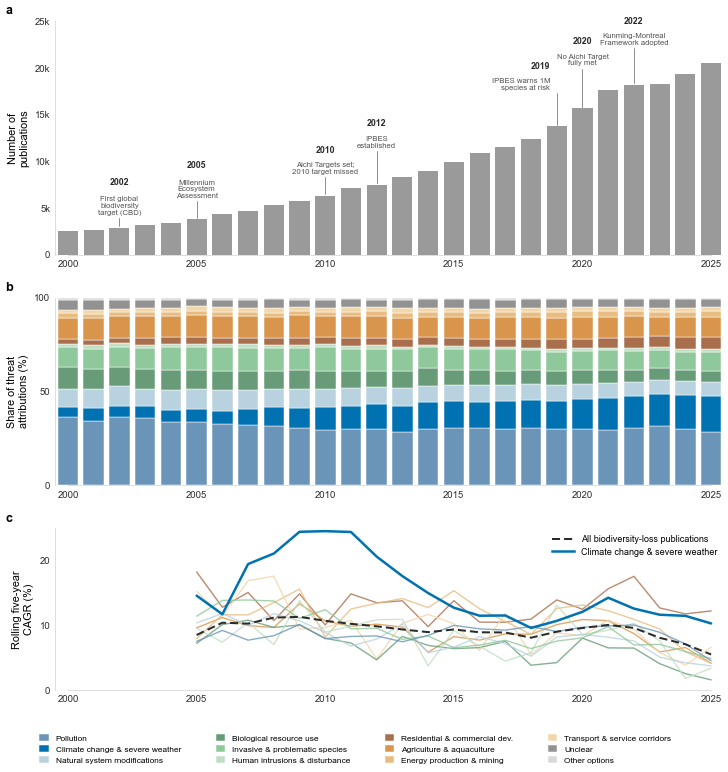

In [7]:
fig, (ax_a, ax_b, ax_c) = plt.subplots(
    3, 1, figsize=(7.6, 7.6), sharex=True,
    gridspec_kw={"height_ratios": [1.80, 1.45, 1.25]},
)
shared_year_ticks = [2000, 2005, 2010, 2015, 2020, 2025]

# A — complete-year publication volume and milestones.
ax_a.bar(
    bar_years, bar_counts, width=0.78,
    color=BAR_GREY, edgecolor="none", zorder=2,
)
description_size = 5.6
description_line_points = description_size * 1.12
for year, description, text_y, alignment, offset in POLICY_EVENTS:
    text_x = year + offset
    ax_a.plot(
        [year, year], [count_by_year[year] + 150, text_y - 250],
        color=LINE_COLOR, linewidth=0.6, zorder=3,
        solid_capstyle="round",
    )
    ax_a.text(
        text_x, text_y, description, ha=alignment, va="bottom",
        fontsize=description_size, color="#555555", linespacing=1.10,
    )
    ax_a.annotate(
        str(year), xy=(text_x, text_y),
        xytext=(
            0,
            (description.count("\n") + 1) * description_line_points + 2,
        ),
        textcoords="offset points", ha=alignment, va="bottom",
        fontsize=6.3, fontweight="bold", color=visualization.BIODIVERSITY["ink"],
    )
ax_a.set_ylim(0, BAND_TOP)
ax_a.set_yticks(Y_TICKS)
ax_a.yaxis.set_major_formatter(
    lambda value, _: f"{value / 1000:.0f}k" if value >= 1000 else f"{value:.0f}"
)
ax_a.set_ylabel("Number of\npublications", fontsize=7.8)

# B — annual threat composition.
bottoms = np.zeros(len(composition_years))
for threat in stack_order:
    values = threat_shares_df[threat].to_numpy()
    ax_b.bar(
        composition_years, values, bottom=bottoms, width=0.8,
        color=THREAT_COLORS[threat],
        edgecolor=visualization.BIODIVERSITY["paper"], linewidth=0.35, zorder=2,
    )
    bottoms += values
ax_b.set_ylim(0, 100)
ax_b.set_yticks([0, 50, 100])
ax_b.set_ylabel("Share of threat\nattributions (%)", fontsize=7.8)

# C — rolling five-year CAGR.
for threat in growth_plot_threats:
    focal = threat == FOCAL_THREAT
    ax_c.plot(
        rolling_end_years, rolling_threat_df[threat],
        color=THREAT_COLORS[threat],
        linewidth=1.8 if focal else 1.0,
        alpha=1.0 if focal else 0.80,
        solid_capstyle="round", zorder=3 if focal else 2,
    )
ax_c.plot(
    rolling_end_years, overall_rolling_cagr,
    color=visualization.BIODIVERSITY["ink"], linewidth=1.45,
    linestyle=(0, (4, 2)), zorder=4,
)
ax_c.set_ylim(y_min, y_max)
ax_c.set_yticks([0, 10, 20])
ax_c.axhline(0, color=visualization.BIODIVERSITY["neutral"], linewidth=0.6, zorder=0)
ax_c.set_ylabel("Rolling five-year\nCAGR (%)", fontsize=7.8)
ax_c.legend(
    handles=[
        Line2D(
            [0], [0], color=visualization.BIODIVERSITY["ink"], linewidth=1.45,
            linestyle=(0, (4, 2)),
            label="All biodiversity-loss publications",
        ),
        Line2D(
            [0], [0], color=THREAT_COLORS[FOCAL_THREAT], linewidth=1.8,
            label="Climate change & severe weather",
        ),
    ],
    loc="upper right", frameon=False, fontsize=6.5,
    handlelength=2.4, labelspacing=0.4, borderaxespad=0.35,
)

for label, axis in zip("abc", (ax_a, ax_b, ax_c)):
    axis.text(
        -0.075, 1.02, label, transform=axis.transAxes,
        fontsize=9.0, fontweight="bold", va="bottom",
    )
    axis.spines[["top", "right"]].set_visible(False)
    axis.spines[["left", "bottom"]].set_color(visualization.BIODIVERSITY["neutral"])
    axis.spines[["left", "bottom"]].set_linewidth(0.6)
    axis.tick_params(
        length=0, colors=visualization.BIODIVERSITY["ink"],
        labelsize=6.8, labelbottom=True,
    )
    axis.grid(False)
    axis.set_xticks(shared_year_ticks)
    axis.spines["bottom"].set_bounds(START_YEAR, END_YEAR)
ax_a.spines["left"].set_bounds(0, BAND_TOP)
ax_b.spines["left"].set_bounds(0, 100)
ax_c.spines["left"].set_bounds(y_min, y_max)
ax_c.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)

fig.legend(
    handles=[
        Patch(
            facecolor=THREAT_COLORS[threat],
            edgecolor=visualization.BIODIVERSITY["paper"], linewidth=0.35,
            label=THREAT_DISPLAY_NAMES[threat],
        )
        for threat in stack_order
    ],
    loc="lower left", ncol=4, mode="expand",
    bbox_to_anchor=(0.08, 0.004, 0.84, 0.09),
    frameon=False, fontsize=6.0, handlelength=1.15,
    handleheight=0.9, columnspacing=1.1,
    labelspacing=0.45, borderaxespad=0.0,
)
fig.subplots_adjust(
    left=0.105, right=0.985, top=0.985,
    bottom=0.105, hspace=0.22,
)
visualization.save_figure(
    fig,
    FIGURE_DIR / TEMPORAL_CONFIG["combined_figure_filename"],
    formats=["pdf"],
    facecolor="white",
)
plt.show()

## 3. Geography of study volume

These maps support no sentence the manuscript currently reports — the Result 1
section makes no geographic claim and no map is referenced in the .tex.

Each map counts **unique publications** per country — never inflated by
multi-label geography mentions (a study naming five countries adds 1 to each,
not 5). Countries are joined to the IPBES polygon reference via
`pred_countries` (ISO 3166-1 alpha-3); non-mappable tokens (`[]`,
`"Not Applicable"`, `"Unclear"`, invalid ISO3) are skipped and reported in the
audit, never dropped silently. This uses the same negative-impact publications
and 2000–2025 analysis window as the rest of this notebook — all study
designs, not restricted to Observational as in the geography section of
`threats_supplementary.ipynb`.

Color is a **YlGn (yellow→green) sequential ramp in fixed order-of-magnitude
classes** (1–9, 10–99, 100–999, …), not a continuous ramp: publication counts
span ~4 orders of magnitude, which is hard to read precisely on any continuous
gradient regardless of hue, and quantile (equal-country) classes were tried
and rejected because the top 20% of countries alone spans 650–26,000 —
collapsing almost the whole well-studied world into one indistinguishable
class. The yellow→green range (rather than single-hue green) gives the lowest
class its own distinct tone instead of blending into the grey zero-fill or the
next class up. Zero-count countries render as a flat, distinct grey rather
than the palest class color, so gaps in the evidence base stay legible. This
is a **magnitude** map, not a research-specialization map — it shows where
biodiversity-loss literature is geolocated, not where threats occur, and the
largest producers partly reflect research capacity and publishing volume
rather than only the underlying prevalence of a threat. For a specialization-
controlled view (location quotient, diverging colors), see the geography
section of `threats_supplementary.ipynb`.

In [8]:
# Country-level publication counts, total and per-threat, joined to the IPBES
# polygon vocabulary. geo_counts parses pred_countries (ISO 3166-1 alpha-3),
# skips non-mappable tokens but reports them, and returns unique-document
# counts (never inflated mention counts): n = documents in the country (and
# threat, when split); group_total = documents in the comparison group; share
# = n / group_total.
geo_source_df = loss_df.loc[
    loss_df["publication_year"].between(START_YEAR, END_YEAR)
].copy()
print(
    f"Geography maps use {geo_source_df['UT'].nunique():,} biodiversity-loss "
    f"publications ({START_YEAR}-{END_YEAR}, all study designs)."
)

geo_country_total_long, geo_country_total_audit = geo_counts(
    geo_source_df, level="country", by=None, id_col="UT", verbose=False
)
geo_country_threat_long, geo_country_threat_audit = geo_counts(
    geo_source_df, level="country", by="pred_threat_l0", id_col="UT", verbose=False
)
print(geo_country_total_audit.summary())

# Enrich with country / region names for readability, then order columns.
crosswalk = load_crosswalk()

geo_country_total_long = (
    geo_country_total_long
    .merge(crosswalk[["iso3", "country", "region", "subregion"]], on="iso3", how="left")
    .rename(columns={"n": "record_count", "group_total": "total_record_count"})
    .loc[:, ["iso3", "country", "region", "subregion",
             "record_count", "total_record_count", "share"]]
    .sort_values("record_count", ascending=False)
    .reset_index(drop=True)
)
geo_country_threat_long = (
    geo_country_threat_long
    .merge(crosswalk[["iso3", "country", "region", "subregion"]], on="iso3", how="left")
    .rename(columns={"n": "record_count", "group_total": "threat_record_count"})
    .loc[:, ["pred_threat_l0", "iso3", "country", "region", "subregion",
             "record_count", "threat_record_count", "share"]]
    .sort_values(["pred_threat_l0", "record_count"], ascending=[True, False])
    .reset_index(drop=True)
)

# Panel order: threats by number of geolocatable documents, descending;
# "Other Options" omitted from the maps (same convention as the threats_supplementary
# geography grids). "Unclear" is kept — it is still meaningful geography.
geo_threat_order = [
    threat
    for threat in (
        geo_country_threat_long.groupby("pred_threat_l0", observed=True)["threat_record_count"]
        .first().sort_values(ascending=False).index.tolist()
    )
    if threat != "Other Options"
]

# Audit as a saveable table: totals plus per-bucket mention counts.
geo_country_audit_table = pd.DataFrame(
    [{"metric": "records_total", "value": geo_country_total_audit.records_total},
     {"metric": "records_without_geography",
      "value": geo_country_total_audit.records_without_geography}]
    + [{"metric": f"mentions_{bucket}", "value": count}
       for bucket, count in geo_country_total_audit.bucket_mentions.items()]
)

save_table(geo_country_total_long, "geo_country_total_long")
save_table(geo_country_threat_long, "geo_country_threat_long")
save_table(geo_country_audit_table, "geo_country_audit")

print("Top 15 countries by total publication count")
display(geo_country_total_long.head(15))

Geography maps use 245,168 biodiversity-loss publications (2000-2025, all study designs).


country: 245,168 records; 15,739 with no geography ([] -> unclear)
    mapped         :  167,341 mentions
    not_applicable :   72,078 mentions
    unclear        :    9,207 mentions
    unresolved     :      873 mentions
    unresolved tokens: TAN (353), MAD (129), ROM (101), BUL (38), DEN (31), CAM (30), NEP (26), KOS (20), POR (13), BAN (12), CRO (8), URU (7), BUR (7), locales [ (5), SLO (5)
Saved: notebooks/results/outputs/01_evidence_growth/csv/geo_country_total_long.csv
Saved: notebooks/results/outputs/01_evidence_growth/csv/geo_country_threat_long.csv
Saved: notebooks/results/outputs/01_evidence_growth/csv/geo_country_audit.csv
Top 15 countries by total publication count


,iso3,country,region,subregion,record_count,total_record_count,share
0,USA,United States of America (the),Americas,North America,25690,147680,0.173957
1,CHN,China,Asia and the Pacific,North-East Asia,20652,147680,0.139843
2,BRA,Brazil,Americas,South America,8668,147680,0.058694
3,CAN,Canada,Americas,North America,6799,147680,0.046039
4,IND,India,Asia and the Pacific,South Asia,6680,147680,0.045233
5,AUS,Australia,Asia and the Pacific,Oceania,6651,147680,0.045037
6,ESP,Spain,Europe and Central Asia,Central and Western Europe,4526,147680,0.030647
7,ITA,Italy,Europe and Central Asia,Central and Western Europe,3850,147680,0.026070
8,MEX,Mexico,Americas,Mesoamerica,3464,147680,0.023456
9,GBR,United Kingdom of Great Britain and Northern I...,Europe and Central Asia,Central and Western Europe,2892,147680,0.019583


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_total_choropleth.pdf


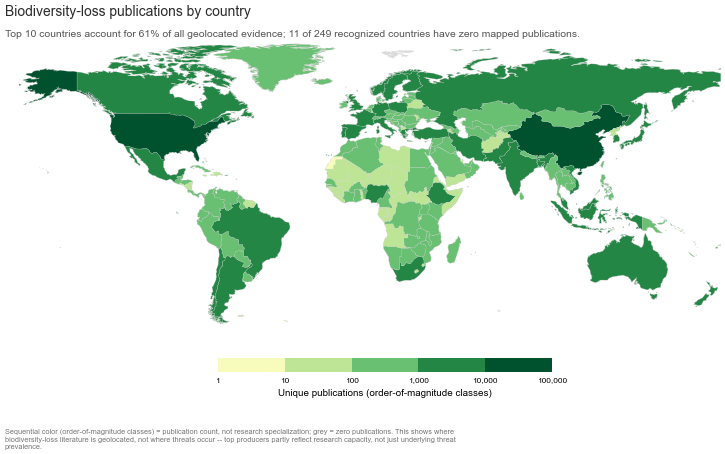

In [9]:
# Total-volume choropleth: unique publications per country. Counts span ~4
# orders of magnitude (1 to 25,690), which is inherently hard to read on a
# continuous gradient no matter the colormap. Discretizing into fixed
# order-of-magnitude classes is what actually fixes legibility -- quantile-
# based (equal-country) classes were tried and rejected because the top 20%
# of countries alone spans 650-26,000, so equal-count bins collapsed almost
# the whole well-studied world into one class. YlGn (yellow -> green) instead
# of single-hue Greens gives the lowest class (1-9) a distinct pale-yellow
# tone, so it no longer blends into either the grey zero-fill or the next
# class up, the way the palest green did. Zero-count countries stay a flat,
# distinct grey, not a ramp color, so gaps in the evidence base stay legible.
GEO_MASK_COLOR = "#D9D9D9"
GEO_MASK_EDGE = visualization.BIODIVERSITY["neutral"]
GEO_CAVEAT = (
    "Sequential color (order-of-magnitude classes) = publication count, not research "
    "specialization; grey = zero publications. This shows where biodiversity-loss "
    "literature is geolocated, not where threats occur -- top producers partly reflect "
    "research capacity, not just underlying threat prevalence."
)


geo_country_polygons = load_polygons(simplify_tolerance=0.2, preserve_topology=False)

# Headline concentration stats, computed against the full recognized-country
# vocabulary (crosswalk iso3, excluding the handful of blank-code disputed
# territories) rather than just the polygons drawn, so the claim is exact.
geo_valid_iso3 = crosswalk.loc[
    crosswalk["iso3"].astype(str).str.strip().ne(""), "iso3"
].unique()
geo_total_universe = int(geo_country_total_long["total_record_count"].iloc[0])
geo_top10_share = (
    geo_country_total_long.nlargest(10, "record_count")["record_count"].sum()
    / geo_total_universe * 100
)
geo_zero_iso3 = set(geo_valid_iso3) - set(geo_country_total_long["iso3"])
GEO_HEADLINE = (
    f"Top 10 countries account for {geo_top10_share:.0f}% of all geolocated evidence; "
    f"{len(geo_zero_iso3)} of {len(geo_valid_iso3)} recognized countries have zero mapped "
    f"publications."
)

geo_total_cmap, geo_total_norm, geo_total_bins = build_count_scale(
    int(geo_country_total_long["record_count"].max())
)

geo_total_merged = geo_country_polygons.merge(
    geo_country_total_long[["iso3", "record_count"]],
    left_on="ISO_3", right_on="iso3", how="left",
)
geo_total_merged["record_count"] = geo_total_merged["record_count"].fillna(0).astype(int)
geo_total_placed = geo_total_merged.loc[geo_total_merged["record_count"] > 0]

fig, ax = plt.subplots(figsize=(7.6, 4.6))
geo_total_merged.plot(ax=ax, color=GEO_MASK_COLOR, edgecolor=GEO_MASK_EDGE, linewidth=0.15)
if len(geo_total_placed):
    geo_total_placed.plot(
        ax=ax, column="record_count", cmap=geo_total_cmap, norm=geo_total_norm,
        edgecolor=GEO_MASK_EDGE, linewidth=0.15,
    )
ax.set_xlim(-170, 180)
ax.set_ylim(-58, 84)
ax.set_axis_off()

fig.suptitle(
    "Biodiversity-loss publications by country",
    x=0.02, y=0.985, ha="left", fontsize=10, color=visualization.BIODIVERSITY["ink"],
)
fig.text(0.02, 0.93, GEO_HEADLINE, ha="left", va="top", fontsize=7.5, color="#555555")

cax = fig.add_axes([0.30, 0.185, 0.44, 0.03])
add_class_colorbar(
    fig, cax, geo_total_cmap, geo_total_norm, geo_total_bins,
    "Unique publications (order-of-magnitude classes)",
)
fig.text(0.02, 0.02, textwrap.fill(GEO_CAVEAT, 150), fontsize=5.3, color="#777777")
fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.28)
save_figure(fig, "geo_country_total_choropleth")
plt.show()

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_threat_choropleth.pdf


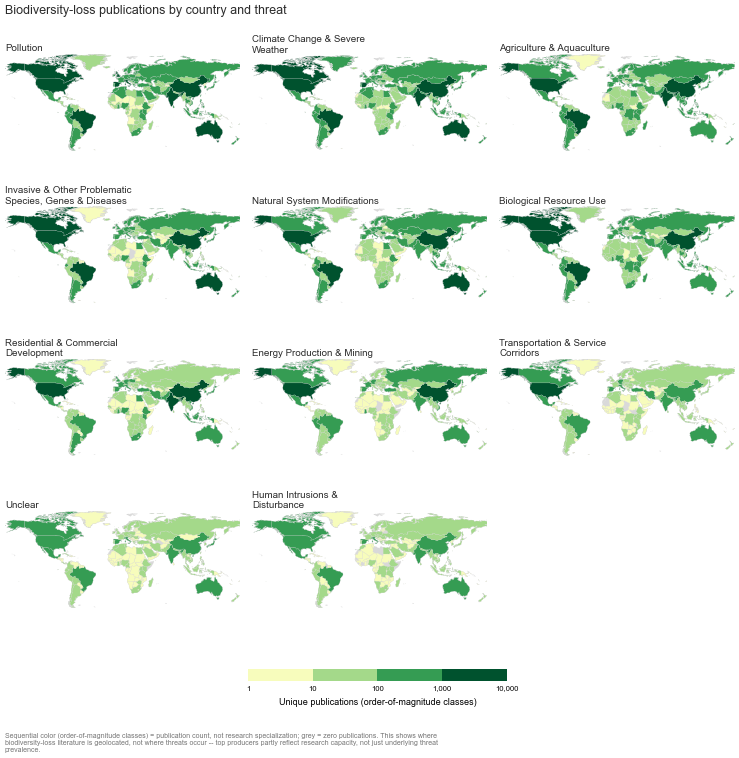

In [10]:
# Per-threat small-multiple grid: same counting/classing convention as the total
# map above, one shared order-of-magnitude scale so panels stay comparable.
geo_threat_cmap, geo_threat_norm, geo_threat_bins = build_count_scale(
    int(geo_country_threat_long["record_count"].max())
)


def plot_geo_threat_grid(polygons, geom_key, count_long, key_col, panel_order, filename):
    n_cols = 3
    n_rows = (len(panel_order) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.6, 1.55 * n_rows + 1.4))
    axes = list(axes.flat)

    for ax, threat in zip(axes, panel_order):
        threat_counts = count_long.loc[
            count_long["pred_threat_l0"].eq(threat), [key_col, "record_count"]
        ]
        merged = polygons.merge(threat_counts, left_on=geom_key, right_on=key_col, how="left")
        merged["record_count"] = merged["record_count"].fillna(0).astype(int)
        placed = merged.loc[merged["record_count"] > 0]
        merged.plot(ax=ax, color=GEO_MASK_COLOR, edgecolor=GEO_MASK_EDGE, linewidth=0.12)
        if len(placed):
            placed.plot(
                ax=ax, column="record_count", cmap=geo_threat_cmap, norm=geo_threat_norm,
                edgecolor=GEO_MASK_EDGE, linewidth=0.12,
            )
        ax.set_xlim(-170, 180)
        ax.set_ylim(-58, 84)
        ax.set_axis_off()
        ax.set_title(
            textwrap.fill(threat, width=28), loc="left", fontsize=7,
            color=visualization.BIODIVERSITY["ink"], pad=2,
        )

    for ax in axes[len(panel_order):]:
        ax.set_visible(False)

    cax = fig.add_axes([0.34, 0.105, 0.34, 0.016])
    add_class_colorbar(
        fig, cax, geo_threat_cmap, geo_threat_norm, geo_threat_bins,
        "Unique publications (order-of-magnitude classes)", fontsize=6.5, tick_fontsize=5.5,
    )

    fig.suptitle(
        "Biodiversity-loss publications by country and threat",
        x=0.02, y=0.995, ha="left", fontsize=9, color=visualization.BIODIVERSITY["ink"],
    )
    fig.text(0.02, 0.012, textwrap.fill(GEO_CAVEAT, 150), fontsize=5.0, color="#777777")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.19, wspace=0.05, hspace=0.35)
    paths = save_figure(fig, filename)
    return paths


geo_threat_grid_paths = plot_geo_threat_grid(
    geo_country_polygons, "ISO_3", geo_country_threat_long, "iso3",
    geo_threat_order, "geo_country_threat_choropleth",
)
plt.show()

### Per-threat maps (individual files for reuse)

The same count map rendered one threat per figure, so each threat's country
map can be referenced or reused on its own. Files are written to
`figures/` as `geo-country-<threat-slug>.pdf`. Classes (order-of-
magnitude, `YlGn`) and colors are identical to the combined grid above.

In [11]:
# Per-threat maps: one standalone count choropleth per threat, each saved to its
# own file so it can be referenced / reused on its own. Same counting, classes,
# and colors as the combined grid above.
def _threat_slug(threat: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", threat.lower()).strip("_")


def plot_geo_threat_single(polygons, geom_key, count_long, key_col, threat, filename):
    fig, ax = plt.subplots(figsize=(5.8, 3.7))

    threat_counts = count_long.loc[
        count_long["pred_threat_l0"].eq(threat), [key_col, "record_count"]
    ]
    merged = polygons.merge(threat_counts, left_on=geom_key, right_on=key_col, how="left")
    merged["record_count"] = merged["record_count"].fillna(0).astype(int)
    placed = merged.loc[merged["record_count"] > 0]
    merged.plot(ax=ax, color=GEO_MASK_COLOR, edgecolor=GEO_MASK_EDGE, linewidth=0.15)
    if len(placed):
        placed.plot(
            ax=ax, column="record_count", cmap=geo_threat_cmap, norm=geo_threat_norm,
            edgecolor=GEO_MASK_EDGE, linewidth=0.15,
        )
    ax.set_xlim(-170, 180)
    ax.set_ylim(-58, 84)
    ax.set_axis_off()
    ax.set_title(
        f"{threat}\nBiodiversity-loss publications by country",
        loc="left", fontsize=9, color=visualization.BIODIVERSITY["ink"], pad=4,
    )

    cax = fig.add_axes([0.30, 0.185, 0.44, 0.025])
    add_class_colorbar(
        fig, cax, geo_threat_cmap, geo_threat_norm, geo_threat_bins,
        "Unique publications (order-of-magnitude classes)",
    )
    fig.text(0.02, 0.015, textwrap.fill(GEO_CAVEAT, 150), fontsize=5.3, color="#777777")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.83, bottom=0.30)

    paths = save_figure(fig, filename)
    plt.close(fig)  # avoid displaying every per-threat figure inline
    return paths


geo_threat_single_paths = {}
for threat in geo_threat_order:
    slug = _threat_slug(threat)
    geo_threat_single_paths[threat] = plot_geo_threat_single(
        geo_country_polygons, "ISO_3", geo_country_threat_long, "iso3",
        threat, f"geo_country_{slug}",
    )

print(f"Saved {len(geo_threat_order)} per-threat country choropleths to "
      f"{FIGURE_DIR}.")
for threat in geo_threat_order:
    print(f"  {_threat_slug(threat)}")

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_pollution.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_climate_change_severe_weather.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_agriculture_aquaculture.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_invasive_other_problematic_species_genes_diseases.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_natural_system_modifications.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_biological_resource_use.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_residential_commercial_development.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_energy_production_mining.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_transportation_service_corridors.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_unclear.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures/geo_country_human_intrusions_disturbance.pdf
Saved 11 per-threat country choropleths to /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/01_evidence_growth/figures.
  pollution
  climate_change_severe_weather
  agriculture_aquaculture
  invasive_other_problematic_species_genes_diseases
  natural_system_modifications
  biological_resource_use
  residential_commercial_development
  energy_production_mining
  transportation_service_corridors
  unclear
  human_intrusions_disturbance


## 4. Export

The audited temporal tables behind the figure, written to `csv/`, followed by a listing of
the PDFs in `figures/`.

In [12]:
for table, filename in (
    (evidence_audit_df, "evidence_audit"),
    (annual_table.loc[annual_table["year_status"].eq("complete")], "annual_publication_counts"),
    (threat_shares_df.reset_index(), "threat_year_shares"),
    (cagr_matrix_df, "threat_cagr_by_period"),
    (rolling_all_df.reset_index(), "rolling_five_year_cagr"),
):
    path = TABLE_DIR / f"{filename}.csv"
    table.to_csv(path, index=False)
    print(path.relative_to(PROJECT_ROOT))
for path in sorted(FIGURE_DIR.glob("*.pdf")):
    print(path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/01_evidence_growth/csv/evidence_audit.csv
notebooks/results/outputs/01_evidence_growth/csv/annual_publication_counts.csv
notebooks/results/outputs/01_evidence_growth/csv/threat_year_shares.csv
notebooks/results/outputs/01_evidence_growth/csv/threat_cagr_by_period.csv
notebooks/results/outputs/01_evidence_growth/csv/rolling_five_year_cagr.csv
notebooks/results/outputs/01_evidence_growth/figures/combined_time_development.pdf
notebooks/results/outputs/01_evidence_growth/figures/geo_country_agriculture_aquaculture.pdf
notebooks/results/outputs/01_evidence_growth/figures/geo_country_biological_resource_use.pdf
notebooks/results/outputs/01_evidence_growth/figures/geo_country_climate_change_severe_weather.pdf
notebooks/results/outputs/01_evidence_growth/figures/geo_country_energy_production_mining.pdf
notebooks/results/outputs/01_evidence_growth/figures/geo_country_human_intrusions_disturbance.pdf
notebooks/results/outputs/01_evidence_growth/figures/geo_country_invas